In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import expit

from multiprocessing import Pool, cpu_count
from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from jax import random
from jax import vmap

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 10,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

W = 5.0
from utils import newfig, fd

import ei_open_loop as eol
import ei_unified as eu


In [2]:
pa= {"nk": 20,
    "gap": 2.0,
    "ta": 1.0,
    "tb": -0.3,
    "v": 2.5,
    "n0": 1.0,
    "t": 0.1,}

In [3]:
b2 = eu.tb_2d(pa["nk"], pa["gap"], pa["ta"], pa["tb"])
b1 = eu.tb_1d(pa["nk"], pa["gap"], pa["ta"], pa["tb"])
bf = eu.free_1d(pa["nk"], 2.0, pa["gap"])
z = eu.reshape_mode(b2.ea, b2)

assert b2.k.shape == (pa["nk"] ** 2, 2)
assert z.shape == (pa["nk"], pa["nk"])
assert np.isclose(np.sum(b2.w), 1.0)
assert b1.dim == bf.dim == 1
print("2D grid:", b2.shape, "modes:", b2.size)
print("1D:", b1.size, bf.size)

z

2D grid: (20, 20) modes: 400
1D: 20 20


array([[ 5.00000000e+00,  4.90211303e+00,  4.61803399e+00,
         4.17557050e+00,  3.61803399e+00,  3.00000000e+00,
         2.38196601e+00,  1.82442950e+00,  1.38196601e+00,
         1.09788697e+00,  1.00000000e+00,  1.09788697e+00,
         1.38196601e+00,  1.82442950e+00,  2.38196601e+00,
         3.00000000e+00,  3.61803399e+00,  4.17557050e+00,
         4.61803399e+00,  4.90211303e+00],
       [ 4.90211303e+00,  4.80422607e+00,  4.52014702e+00,
         4.07768354e+00,  3.52014702e+00,  2.90211303e+00,
         2.28407904e+00,  1.72654253e+00,  1.28407904e+00,
         1.00000000e+00,  9.02113033e-01,  1.00000000e+00,
         1.28407904e+00,  1.72654253e+00,  2.28407904e+00,
         2.90211303e+00,  3.52014702e+00,  4.07768354e+00,
         4.52014702e+00,  4.80422607e+00],
       [ 4.61803399e+00,  4.52014702e+00,  4.23606798e+00,
         3.79360449e+00,  3.23606798e+00,  2.61803399e+00,
         2.00000000e+00,  1.44246348e+00,  1.00000000e+00,
         7.15920956e-01,  6.1

findfont: Failed to find font weight normal, now using 300.


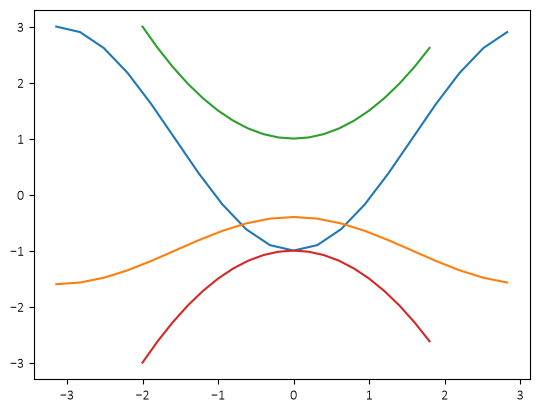

In [4]:
plt.plot(b1.k, b1.ea)
plt.plot(b1.k, b1.eb)
plt.plot(bf.k, bf.ea)
plt.plot(bf.k, bf.eb)


In [5]:
kx = eu.reshape_mode(b2.k[:, 0], b2)
ky = eu.reshape_mode(b2.k[:, 1], b2)

ea2 = eu.reshape_mode(b2.ea, b2)
eb2 = eu.reshape_mode(b2.eb, b2)

findfont: Failed to find font weight normal, now using 300.


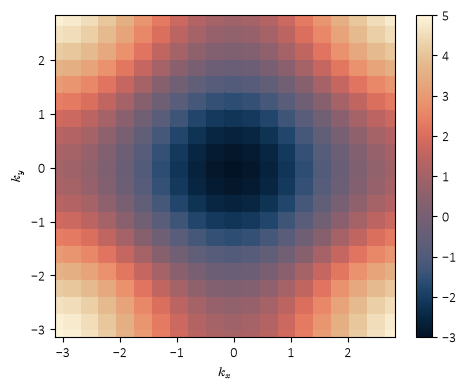

In [6]:
h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    ea2,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

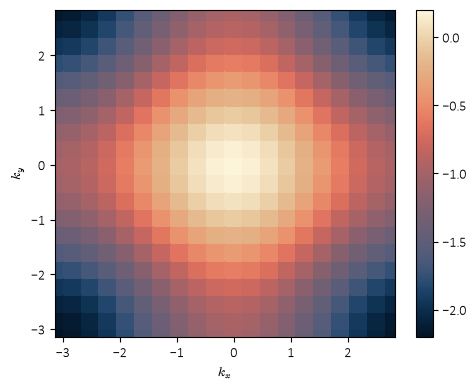

In [7]:
h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    eb2,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

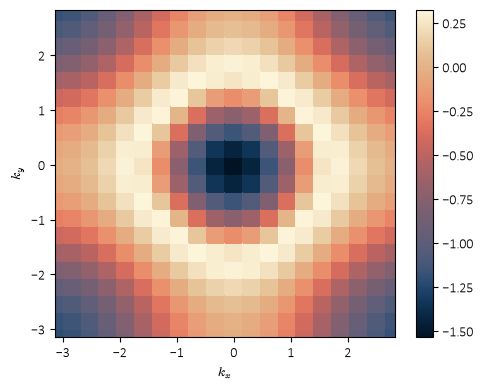

In [8]:
p = eu.MFPars(pa["v"], pa["n0"]) #dataclass za V, n_a+n_b in U_H
p.h #vrne v=uh, če uh==None, sicer uh

st = eu.mf_state(b2, p, d=0.3, m=-0.2) # diagonalizira MF hamiltonko, vzame band, V, n0, delta in m
eu.reshape_mode(st.e, b2) #diagonalizirana hamiltonka, [0] je sponji pas, [1] zgornji, reshaped nazaj (deflattened)

h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    eu.reshape_mode(st.e, b2)[1],
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

FD kemijski potencial:   0%|          | 0/120 [00:00<?, ?it/s]

0.5898770270324951
(20, 20)


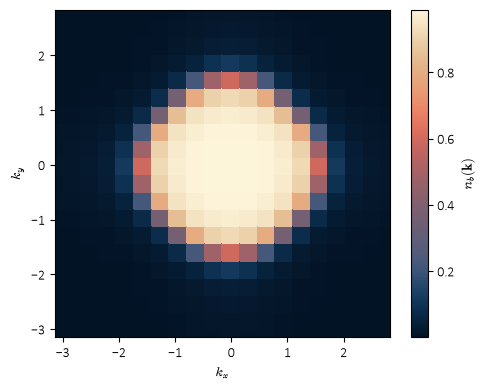

In [9]:
fs = eu.fermi(st, pa["t"], prog=True) #izracuna mu, iz ∑​wk​[f(Eαk​−μ)+f(Eβk​−μ)]=n0​, n0 dobi iz MFState
print(fs.mu)


na, nb = eu.band_occ(st, fs.n) #transformira v n_a in n_b (original bazo)

na = eu.reshape_mode(na, st.bd) #reshae v 2d grid

h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    na,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$n_b(\mathbf{k})$", rotation=90, labelpad=5)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()
print(na.shape) #na(k)

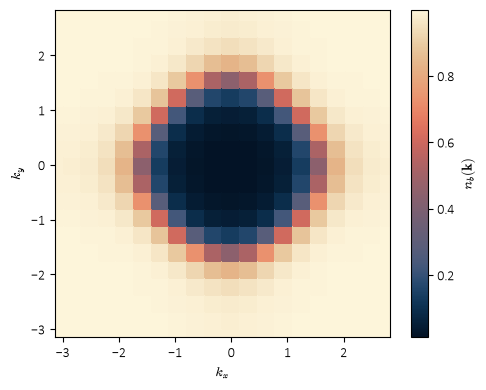

In [10]:
nb = eu.reshape_mode(nb, st.bd) #reshae v 2d grid

h = 0.8
fig, ax = plt.subplots(figsize=(5, h * 5))

im = ax.pcolormesh(
    kx,
    ky,
    nb,
    shading="auto",
    cmap=cmaps.lipari,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$n_b(\mathbf{k})$", rotation=90, labelpad=5)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

In [11]:
tg = eu.targets(st, fs.n) #vzame MFState in n_alpha, beta
tg #vrne delta, n_a-n_b, n0, n_a, n_b

Targets(d=0.3746508826743882, m=-0.5977294459394008, n=0.9999999999999989, na=0.20113527703029913, nb=0.7988647229696999)

test tokovi

In [12]:
ga = eu.gam_db(pa["t"], kap=0.3, wc=5.0, orb=None)
r = ga(st, fs.n)
h = 0.8
from matplotlib.colors import LogNorm

rp = r[r > 0.0]

norm = LogNorm(
    vmin=np.percentile(rp, 1),
    vmax=rp.max(),
)

In [13]:
p0 = np.argmin(np.sum(st.bd.k**2, axis=1))

# beta,p0 to alpha,k
rk = eu.reshape_mode(r[0, :, 1, p0], st.bd)

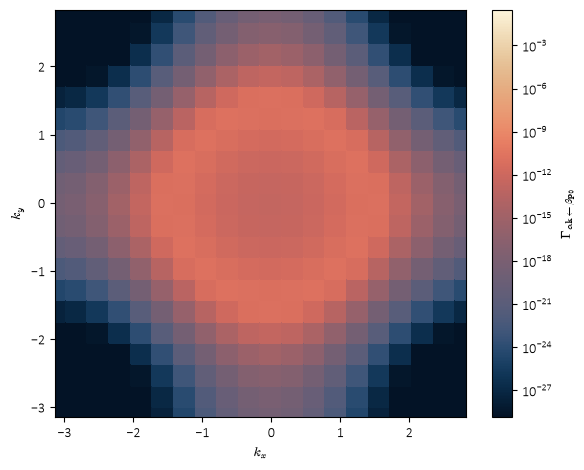

In [14]:
h = 0.8
fig, ax = plt.subplots(figsize=(6, h * 6))

im = ax.pcolormesh(
    kx,
    ky,
    rk,
    shading="auto",
    cmap=cmaps.lipari,
    norm=norm
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(
    r"$\Gamma_{\alpha\mathbf{k}\leftarrow\beta\mathbf{p}_0}$",
    rotation=90,
    labelpad=5,
)

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())

plt.tight_layout()

toy model 1d tight binding, custom trnasition rates

In [45]:
db = eu.check_db(r, st, pa["t"]) #preveri detailed balance residual
db
dn = eu.dense_current(fs.n, r, st) #poracuna \dot(n_k), shape [2, nk**2]
print(r.shape)
print(dn.shape)
nr = eu.number_rate(dn, st.bd) # poracuna celoten current, sesteto po k, weights w_k
print(nr)


#toy rates, 0 za a==b in k==q, ostali transitioni kosntantni
rs = eu.gam_scalar(
    lambda a, k, b, q, s, n: 0.0 if (a == b and k == q) else 0.01
)
bt = eu.tb_1d(nk=30, gap=0.1, ta=1.0, tb=-0.3) #1d tight binding toy primer
pt = eu.MFPars(1.0)
stt = eu.mf_state(bt, pt, 0.1, 0.0)
nt = eu.fermi(stt, 0.2).n
rt = rs(stt, nt)

(2, 400, 2, 400)
(2, 400)
1.302237357387841e-19


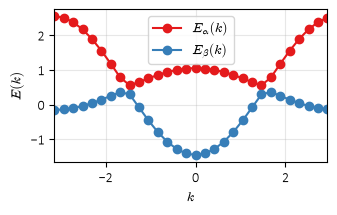

In [46]:
k = bt.k[:, 0]
ix = np.argsort(k)

h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k[ix],
    stt.e[0, ix],
    color=set1_list[0],
    marker="o",
    label=r"$E_\alpha(k)$",
)

ax.plot(
    k[ix],
    stt.e[1, ix],
    color=set1_list[1],
    marker="o",
    label=r"$E_\beta(k)$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$E(k)$")
ax.set_xlim(k[ix][0], k[ix][-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

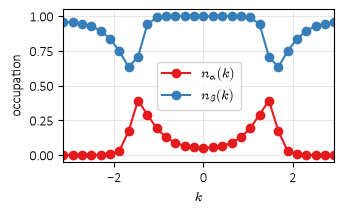

In [47]:
h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k[ix],
    nt[0, ix],
    color=set1_list[0],
    marker="o",
    label=r"$n_\alpha(k)$",
)

ax.plot(
    k[ix],
    nt[1, ix],
    color=set1_list[1],
    marker="o",
    label=r"$n_\beta(k)$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"occupation")
ax.set_xlim(k[ix][0], k[ix][-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [48]:
dn = eu.dense_current(nt, rt, stt)

print("Number rate:", eu.number_rate(dn, bt))
print("Detailed-balance error:", eu.check_db(rt, stt, 0.2))

Number rate: 8.029872339970767e-19
Detailed-balance error: 20.038461287332662


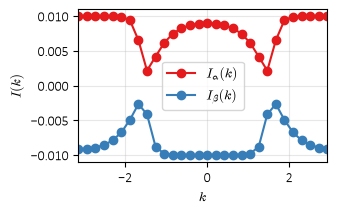

In [49]:
h = 0.65
fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))

ax.plot(
    k[ix],
    dn[0, ix],
    color=set1_list[0],
    marker="o",
    label=r"$I_\alpha(k)$",
)

ax.plot(
    k[ix],
    dn[1, ix],
    color=set1_list[1],
    marker="o",
    label=r"$I_\beta(k)$",
)

ax.set_xlabel(r"$k$")
ax.set_ylabel(r"$I(k)$")
ax.set_xlim(k[ix][0], k[ix][-1])
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [52]:
h = eu.lim_step(np.array([[0.9]]), np.array([[1.0]]), 1.0) #omeji korak, da ostane n_k <= 1
print(h)

0.07999999999999999


check za stacionarne/no bath pogoje

In [53]:
sn = eu.solve_normal(b2, p, pa["t"], prog=True)
la, _ = eu.pair_lambda(b2, p, pa["t"], m=sn.m)
tc = eu.critical_temperature(
    b2,
    p,
    tlo=0.01,
    thi=2.0,
    tol=1.0e-6,
    nmax=50,
    prog=True,
)
se = eu.solve_eq(
    b2,
    p,
    pa["t"],
    d=0.4,
    m=0.0,
    mix=(0.2, 0.2),
    tol=1.0e-9,
    nmax=10000,
    chk=20,
    prog=True,
)

print("Normal m:", sn.m)
print("Pair eigenvalue:", la)
print("Tc:", tc)
print("Equilibrium Delta, m, mu:", se.d, se.m, se.mu)

Normal state:   0%|          | 0/10000 [00:00<?, ?it/s]

Critical temperature:   0%|          | 0/50 [00:00<?, ?it/s]

Equilibrium EI:   0%|          | 0/10000 [00:00<?, ?it/s]

Normal m: -0.863710806862442
Pair eigenvalue: 1.128370097289479
Tc: 0.1482959246635437
Equilibrium Delta, m, mu: 0.26965604266467724 -0.8448541159459056 0.16008439101427024


In [ ]:
from __future__ import annotations

import argparse
import importlib.util
import sys
import types
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import ei_unified as eu


def test_eq(bd, p, pa):
    print("\n4. Equilibrium and critical-temperature solvers")
    sn = eu.solve_normal(bd, p, pa["t"], prog=True)
    la, _ = eu.pair_lambda(bd, p, pa["t"], m=sn.m)
    tc = eu.critical_temperature(
        bd,
        p,
        tlo=0.01,
        thi=2.0,
        tol=1.0e-6,
        nmax=50,
        prog=True,
    )
    se = eu.solve_eq(
        bd,
        p,
        pa["t"],
        d=0.4,
        m=0.0,
        mix=(0.2, 0.2),
        tol=1.0e-9,
        nmax=10000,
        chk=20,
        prog=True,
    )
    assert sn.ok and se.ok
    assert pa["t"] < tc
    assert la > 1.0 and se.d > 0.0
    print("Normal m:", sn.m)
    print("Pair eigenvalue:", la)
    print("Tc:", tc)
    print("Equilibrium Delta, m, mu:", se.d, se.m, se.mu)
    return se, tc


def test_open(bd, p, pa, se):
    print("\n5. Equal-temperature two-bath solver")
    di = 0.8 * se.d
    mi = np.clip(se.m + 0.03, -0.99, 0.99)
    si = eu.mf_state(bd, p, di, mi)
    ni = eu.fermi(si, 1.5 * pa["t"]).n

    d1 = eu.Dissipator(
        eu.gam_db(pa["t"], kap=0.3, wc=5.0),
        name="bath 1",
    )
    d2 = eu.Dissipator(
        eu.gam_db(pa["t"], kap=0.3, wc=5.0),
        name="bath 2",
    )
    dn = eu.total_current((d1, d2), si, ni)
    assert abs(eu.number_rate(dn, bd)) < 1.0e-12

    so = eu.solve_open(
        bd,
        p,
        ni,
        (d1, d2),
        d=di,
        m=mi,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-7,
        nmax=10000,
        chk=10,
        prog=True,
    )
    nf = eu.fermi(so.st, pa["t"]).n
    assert so.ok
    assert np.max(np.abs(so.n - nf)) < 2.0e-5
    print("Open Delta, m:", so.d, so.m)
    print("FD error:", np.max(np.abs(so.n - nf)))
    print("Open residual:", so.err)
    return so


def _stubs():
    if importlib.util.find_spec("tqdm") is None:
        z = types.ModuleType("tqdm")
        z.tqdm = lambda x, *a, **k: x
        sys.modules["tqdm"] = z
    if importlib.util.find_spec("colormaps") is None:
        sys.modules["colormaps"] = types.ModuleType("colormaps")
    if importlib.util.find_spec("labellines") is None:
        z = types.ModuleType("labellines")
        z.labelLines = lambda *a, **k: None
        sys.modules["labellines"] = z
    if importlib.util.find_spec("jax") is None:
        z = types.ModuleType("jax")
        z.random = types.ModuleType("jax.random")
        z.vmap = lambda f, *a, **k: f
        sys.modules["jax"] = z
        sys.modules["jax.numpy"] = np
        sys.modules["jax.random"] = z.random


def load_utils():
    _stubs()
    cand = ("utils.py")
    path = next((q for q in cand if q.exists()), None)
    if path is None:
        raise FileNotFoundError("Place utils.py beside this runner")
    sp = importlib.util.spec_from_file_location("utils_ref", path)
    md = importlib.util.module_from_spec(sp)
    sys.modules[sp.name] = md
    sp.loader.exec_module(md)
    return md


def test_utils(pa, se, so):
    print("\n6. Validation against utils.py")
    old = load_utils()
    bd = old.sq(pa["nk"], pa["gap"], pa["ta"], pa["tb"])
    p = old.Pars(v=pa["v"], t=pa["t"], n=pa["n0"], uh=None)
    sr = old.solve(bd, p, y0=(se.d, se.m, se.mu), tol=1.0e-10, nmax=3000)

    ed = abs(se.d - sr.d)
    em = abs(se.m - sr.m)
    eu0 = abs(se.mu - sr.mu)
    bd0 = abs(so.d - sr.d)
    bm0 = abs(so.m - sr.m)

    assert ed < 1.0e-7 and em < 1.0e-7 and eu0 < 1.0e-7
    assert bd0 < 5.0e-4 and bm0 < 5.0e-4
    print("                     utils        unified       two baths")
    print(f"Delta       {sr.d:14.10f} {se.d:14.10f} {so.d:14.10f}")
    print(f"m           {sr.m:14.10f} {se.m:14.10f} {so.m:14.10f}")
    print(f"Delta diff                 {ed:10.3e} {bd0:14.3e}")
    print(f"m diff                     {em:10.3e} {bm0:14.3e}")
    return sr


def _seg(a, b, nq):
    z = np.linspace(0.0, 1.0, nq, endpoint=False)
    return a[None, :] + z[:, None] * (b - a)[None, :]


def plot_disp(pa, se):
    nq = 100
    g = np.array([0.0, 0.0])
    x = np.array([np.pi, 0.0])
    m = np.array([np.pi, np.pi])
    k = np.vstack((_seg(g, x, nq), _seg(x, m, nq),
                   _seg(m, g, nq), g[None, :]))
    s = np.concatenate(([0.0], np.cumsum(np.linalg.norm(np.diff(k, axis=0), axis=1))))
    c = np.cos(k[:, 0]) + np.cos(k[:, 1])
    ea = 0.5 * pa["gap"] - 2.0 * pa["ta"] * c
    eb = -0.5 * pa["gap"] - 2.0 * pa["tb"] * c
    na = 0.5 * (pa["n0"] + se.m)
    nb = 0.5 * (pa["n0"] - se.m)
    eah = ea + pa["v"] * nb
    ebh = eb + pa["v"] * na
    av = 0.5 * (eah + ebh)
    xi = 0.5 * (eah - ebh)
    ek = np.sqrt(xi * xi + se.d * se.d)

    h = 0.8
    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))
    ax.plot(s, eah, "--", color=set1_list[0], label=r"$\epsilon_a^{\rm H}$")
    ax.plot(s, ebh, "--", color=set1_list[1], label=r"$\epsilon_b^{\rm H}$")
    ax.plot(s, av + ek, color=set1_list[2], label=r"$E_\alpha$")
    ax.plot(s, av - ek, color=set1_list[3], label=r"$E_\beta$")
    ix = np.array([0, nq, 2 * nq, 3 * nq])
    ax.set_xticks(s[ix])
    ax.set_xticklabels([r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"])
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$E(k)$")
    ax.set_xlim(s[0], s[-1])
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
              mode="expand", borderaxespad=0, ncol=2)
    plt.tight_layout()


def plot_conv(se, so):
    z = so.hist
    x = z["t"]
    h = 0.7
    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))
    ax.plot(x, z["d"], color=set1_list[0], label=r"$\Delta_{\rm bath}$")
    ax.plot(x, np.full_like(x, se.d), "--", color=set1_list[1],
            label=r"$\Delta_{\rm eq}$")
    ax.plot(x, z["m"], color=set1_list[2], label=r"$m_{\rm bath}$")
    ax.plot(x, np.full_like(x, se.m), "--", color=set1_list[3],
            label=r"$m_{\rm eq}$")
    ax.set_xlabel(r"$t_{\rm rel}$")
    ax.set_ylabel(r"self-consistent fields")
    ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.3)
    ax.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
              mode="expand", borderaxespad=0, ncol=2)
    plt.tight_layout()


def plot_fd(pa, so):
    nf = eu.fermi(so.st, pa["t"])
    x = np.linspace(so.st.e.min(), so.st.e.max(), 300)
    f = 1.0 / (np.exp(np.clip((x - nf.mu) / pa["t"], -700.0, 700.0)) + 1.0)
    h = 0.7
    fig, ax = plt.subplots(figsize=(3.47412, h * 3.47412))
    ax.scatter(so.st.e[0], so.n[0], s=8, color=set1_list[0], label=r"$n_\alpha$")
    ax.scatter(so.st.e[1], so.n[1], s=8, color=set1_list[1], label=r"$n_\beta$")
    ax.plot(x, f, color=set1_list[2], label=r"$f(E)$")
    ax.set_xlabel(r"$E$")
    ax.set_ylabel(r"occupation")
    ax.set_xlim(x[0], x[-1])
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--nk", type=int, default=9)
    ap.add_argument("--no-plots", action="store_true")
    ar = ap.parse_args()

    pa = pars(ar.nk)
    bd = test_bands(pa)
    p, st, fs = test_mf(bd, pa)
    test_rates(st, fs, pa)
    se, tc = test_eq(bd, p, pa)
    so = test_open(bd, p, pa, se)
    test_utils(pa, se, so)

    print("\nAll validation checks passed")
    print("Tc:", tc)

    if not ar.no_plots:
        plot_disp(pa, se)
        plot_conv(se, so)
        plot_fd(pa, so)
        plt.show()



In [10]:
pa = pars(15)
bd = test_bands(pa)
p, st, fs = test_mf(bd, pa)
test_rates(st, fs, pa)
se, tc = test_eq(bd, p, pa)
so = test_open(bd, p, pa, se)
test_utils(pa, se, so)

print("\nAll validation checks passed")
print("Tc:", tc)

if not ar.no_plots:
    plot_disp(pa, se)
    plot_conv(se, so)
    plot_fd(pa, so)
    plt.show()


1. Band constructors
2D grid: (15, 15) modes: 225
1D constructors: 11 11 13

2. Mean field, FD state, and observables


FD chemical potential:   0%|          | 0/120 [00:00<?, ?it/s]

Default UH: 2.5
FD filling: 0.999999999999996 mu: 0.5862657327320526
Targets: 0.375367134204439 -0.5959612003224145

3. Gamma functions and kinetic current
Rate shape: (2, 225, 2, 225)
Detailed-balance error: 1.4210854715202004e-14
Weighted number rate: -3.1453413200025114e-21

4. Equilibrium and critical-temperature solvers


Normal state:   0%|          | 0/10000 [00:00<?, ?it/s]

Critical temperature:   0%|          | 0/50 [00:00<?, ?it/s]

Equilibrium EI:   0%|          | 0/10000 [00:00<?, ?it/s]

Normal m: -0.8661613738659744
Pair eigenvalue: 1.1157094603541442
Tc: 0.1471306681632995
Equilibrium Delta, m, mu: 0.2670714976636633 -0.8464032422076606 0.16123264639970836

5. Equal-temperature two-bath solver


Open EI:   0%|          | 0/10000 [00:00<?, ?it/s]

Open Delta, m: 0.26706367985839446 -0.8464041140369896
FD error: 1.0155665730010588e-05
Open residual: 9.852978008874705e-08

6. Validation against utils.py


ValueError: colormaps.__spec__ is not set